In [101]:
#import numpy as np
#from scipy.signal import get_window
#
#def compute_spod(
#    u_data,
#    v_data, 
#    dt=1.0,
#    nperseg=128,
#    noverlap=None,
#    window="hann",
#    nfft=None,
#    remove_mean=True,
#    return_eigs=True,
#):
#    """
#    Compute frequency-domain SPOD for combined u and v velocity fields.
#
#    Parameters
#    ----------
#    u_data : ndarray, shape (nx, nt)
#        u-velocity time series.
#    v_data : ndarray, shape (nx, nt)
#        v-velocity time series.
#
#    dt : float, optional
#        Time step.
#
#    nperseg : int, optional
#        Window length for each SPOD ensemble.
#
#    noverlap : int, optional
#        Number of overlapping samples between windows.
#        Default: nperseg // 2.
#
#    window : str or array_like, optional
#        Window function passed to scipy.signal.get_window.
#
#    nfft : int, optional
#        FFT length. Default = nperseg.
#
#    remove_mean : bool, optional
#        Remove temporal mean before SPOD.
#
#    return_eigs : bool, optional
#        Whether to return eigenvalues.
#
#    Returns
#    -------
#    freqs : ndarray, shape (nfreq,)
#        Frequency vector.
#
#    spod_modes : ndarray, shape (nfreq, nmodes, 2*nx)
#        SPOD modes.
#        First nx entries correspond to u,
#        next nx entries correspond to v.
#
#    eigvals : ndarray, shape (nfreq, nmodes)
#        SPOD eigenvalues (energy spectra).
#        Returned only if return_eigs=True.
#
#    Notes
#    -----
#    Input shape:
#        u_data.shape = (nx, nt)
#        v_data.shape = (nx, nt)
#
#    Combined state vector:
#        q(t) = [u(x,t), v(x,t)]^T
#
#    The function performs SPOD jointly on both components.
#    """
#
#    # -------------------------------
#    # Checks
#    # -------------------------------
#    if u_data.shape != v_data.shape:
#        raise ValueError("u_data and v_data must have the same shape")
#    # Plot leading mode in red, others in gray with decreasing alpha
#    if len(mode_indices) == 0:
#        mode_indices = tuple(range(eigvals_plot.shape[1]))
#
#    lead_mode = mode_indices[0]
#    ax.plot(
#        St,
#        eigvals_plot[:, lead_mode],
#        color="red",
#        linestyle='-',
#        linewidth=2,
#        label=f"Mode {lead_mode+1}",
#    )
#
#    other_modes = mode_indices[1:]
#    n_other = len(other_modes)
#    if n_other > 0:
#        alphas = np.linspace(0.8, 0.2, n_other)
#        for i, m in enumerate(other_modes):
#            ax.plot(
#                St,
#                eigvals_plot[:, m],
#                color="0.5",
#                linestyle='-',
#                linewidth=1.25,
#                alpha=float(alphas[i]),
#            )
#        nfft = nperseg
#
#    step = nperseg - noverlap
#
#    if nt < nperseg:
#        raise ValueError("nt must be >= nperseg")
#
#    # -------------------------------
#    # Combine dataset
#    # Shape: (2*nx, nt)
#    # -------------------------------
#    X = np.vstack([u_data, v_data])
#
#    # Remove temporal mean
#    if remove_mean:
#        X = X - np.mean(X, axis=1, keepdims=True)
#
#    ndof = X.shape[0]
#
#    # -------------------------------
#    # Windowing setup
#    # -------------------------------
#    win = get_window(window, nperseg)
#    win_norm = np.sqrt(np.mean(win**2))
#
#    # Number of blocks
#    n_blocks = (nt - noverlap) // step
#
#    if n_blocks < 2:
#        raise ValueError("Need at least 2 blocks for SPOD")
#
#    # Positive frequencies
#    nfreq = nfft // 2 + 1
#    freqs = np.fft.rfftfreq(nfft, d=dt)
#
#    # Fourier realizations
#    # Shape: (nfreq, ndof, n_blocks)
#    Q_hat = np.zeros((nfreq, ndof, n_blocks), dtype=np.complex128)
#
#    # -------------------------------
#    # FFT for each block
#    # -------------------------------
#    for b in range(n_blocks):
#        start = b * step
#        end = start + nperseg
#
#        block = X[:, start:end]
#
#        # Apply window
#        block = block * win[None, :]
#
#        # FFT
#        fft_block = np.fft.rfft(block, n=nfft, axis=1)
#
#        # Normalize
#        fft_block /= np.sqrt(nperseg * win_norm**2)
#
#        Q_hat[:, :, b] = fft_block.T
#
#    # -------------------------------
#    # SPOD eigen decomposition
#    # -------------------------------
#    nmodes = n_blocks
#
#    spod_modes = np.zeros(
#        (nfreq, nmodes, ndof),
#        dtype=np.complex128
#    )
#
#    eigvals = np.zeros((nfreq, nmodes))
#
#    for fi in range(nfreq):
#
#        # Shape: (ndof, n_blocks)
#        Qf = Q_hat[fi]
#
#        # Cross-spectral density matrix
#        # Shape: (n_blocks, n_blocks)
#        S = (Qf.conj().T @ Qf) / n_blocks
#
#        # Eigendecomposition
#        lam, V = np.linalg.eigh(S)
#
#        # Descending order
#        idx = np.argsort(lam)[::-1]
#        lam = lam[idx]
#        V = V[:, idx]
#
#        # Compute SPOD modes
#        Phi = Qf @ V
#
#        # Normalize modes
#        for m in range(nmodes):
#            norm = np.linalg.norm(Phi[:, m])
#            if norm > 0:
#                Phi[:, m] /= norm
#
#        spod_modes[fi] = Phi.T
#        eigvals[fi] = np.real(lam)
#
#    if return_eigs:
#        return freqs, spod_modes, eigvals
#
#    return freqs, spod_modes

In [102]:
import numpy as np
from scipy.signal import get_window


def compute_spod(
    u_data,
    v_data,
    dt=1.0,
    nperseg=128,
    noverlap=None,
    window="hann",
    nfft=None,
    remove_mean=True,
    return_eigs=True,
):
    """
    Compute frequency-domain SPOD for combined u and v velocity fields.

    Parameters
    ----------
    u_data : ndarray, shape (nx, nt)
        u-velocity time series.

    v_data : ndarray, shape (nx, nt)
        v-velocity time series.

    dt : float, optional
        Time step.

    nperseg : int, optional
        Window length for each SPOD ensemble.

    noverlap : int, optional
        Number of overlapping samples between windows.
        Default = nperseg // 2.

    window : str or array_like, optional
        Window function passed to scipy.signal.get_window.

    nfft : int, optional
        FFT length. Default = nperseg.

    remove_mean : bool, optional
        Remove temporal mean before SPOD.

    return_eigs : bool, optional
        Whether to return eigenvalues.

    Returns
    -------
    freqs : ndarray, shape (nfreq,)
        Frequency vector.

    spod_modes : ndarray, shape (nfreq, nmodes, 2*nx)
        SPOD modes.
        First nx entries correspond to u,
        next nx entries correspond to v.

    eigvals : ndarray, shape (nfreq, nmodes)
        SPOD eigenvalues (energy spectra).
        Returned only if return_eigs=True.
    """

    # -------------------------------------------------
    # Checks
    # -------------------------------------------------
    if u_data.shape != v_data.shape:
        raise ValueError(
            "u_data and v_data must have the same shape"
        )

    nx, nt = u_data.shape

    if noverlap is None:
        noverlap = nperseg // 2

    if nfft is None:
        nfft = nperseg

    step = nperseg - noverlap

    if step <= 0:
        raise ValueError(
            "noverlap must be smaller than nperseg"
        )

    if nt < nperseg:
        raise ValueError(
            "nt must be >= nperseg"
        )

    # -------------------------------------------------
    # Combine dataset
    # Shape: (2*nx, nt)
    # -------------------------------------------------
    X = np.vstack([u_data, v_data])

    # Remove temporal mean
    if remove_mean:
        X = X - np.mean(X, axis=1, keepdims=True)

    ndof = X.shape[0]

    # -------------------------------------------------
    # Windowing setup
    # -------------------------------------------------
    win = get_window(window, nperseg)

    # RMS normalization of window
    win_norm = np.sqrt(np.mean(win**2))

    # Number of overlapping blocks
    n_blocks = (nt - noverlap) // step

    if n_blocks < 2:
        raise ValueError(
            "Need at least 2 blocks for SPOD"
        )

    # Positive frequencies
    nfreq = nfft // 2 + 1
    freqs = np.fft.rfftfreq(nfft, d=dt)

    # Fourier realizations
    # Shape: (nfreq, ndof, n_blocks)
    Q_hat = np.zeros(
        (nfreq, ndof, n_blocks),
        dtype=np.complex128
    )

    # -------------------------------------------------
    # FFT for each block
    # -------------------------------------------------
    for b in range(n_blocks):

        start = b * step
        end = start + nperseg

        block = X[:, start:end]

        # Apply window
        block = block * win[None, :]

        # FFT
        fft_block = np.fft.rfft(
            block,
            n=nfft,
            axis=1
        )

        # Normalize
        fft_block /= np.sqrt(
            nperseg * win_norm**2
        )

        # Store as (nfreq, ndof)
        Q_hat[:, :, b] = fft_block.T

    # -------------------------------------------------
    # SPOD eigen decomposition
    # -------------------------------------------------
    nmodes = n_blocks

    spod_modes = np.zeros(
        (nfreq, nmodes, ndof),
        dtype=np.complex128
    )

    eigvals = np.zeros(
        (nfreq, nmodes)
    )

    for fi in range(nfreq):

        # Shape: (ndof, n_blocks)
        Qf = Q_hat[fi]

        # Temporal CSD matrix
        # Shape: (n_blocks, n_blocks)
        S = (
            Qf.conj().T @ Qf
        ) / n_blocks

        # Eigendecomposition
        lam, V = np.linalg.eigh(S)

        # Descending order
        idx = np.argsort(lam)[::-1]

        lam = lam[idx]
        V = V[:, idx]

        # Compute SPOD modes
        # Shape: (ndof, nmodes)
        Phi = Qf @ V

        # Proper SPOD normalization
        for m in range(nmodes):

            norm = np.linalg.norm(
                Phi[:, m]
            )

            if norm > 0:
                Phi[:, m] /= norm

        spod_modes[fi] = Phi.T
        eigvals[fi] = np.real(lam)

    if return_eigs:
        return freqs, spod_modes, eigvals

    return freqs, spod_modes

## Function to obtain spod modal energy

In [103]:
import numpy as np
import matplotlib.pyplot as plt


def plot_spod_modal_energy(
    freqs,
    eigvals,
    D,
    U_ref,
    mode_indices=None,
    normalize="global",
    xlim=None,
    ylim=None,
    logy=True,
    figsize=(7, 5),
):
    """
    Plot normalized SPOD modal energy vs Strouhal number.

    Parameters
    ----------
    freqs : ndarray, shape (nfreq,)
        Frequency vector from compute_spod().

    eigvals : ndarray, shape (nfreq, nmodes)
        SPOD eigenvalues.

    D : float
        Characteristic length scale.

    U_ref : float
        Reference velocity.

    mode_indices : tuple/list or None, optional
        Modes to plot.

        Examples:
            (0,)       -> first mode only
            (0,1,2)    -> first three modes
            None       -> plot all modes

    normalize : str, optional
        "global" : divide by maximum eigenvalue
        "mode"   : normalize each mode independently
        "sum"    : divide by total modal energy

    Returns
    -------
    fig, ax
    """

    # ---------------------------------
    # Strouhal number
    # ---------------------------------
    St = freqs * D / U_ref

    # ---------------------------------
    # Normalize energy
    # ---------------------------------
    eigvals_plot = eigvals.copy()

    if normalize == "global":
        eigvals_plot /= np.max(eigvals)

    elif normalize == "mode":
        for m in range(eigvals.shape[1]):
            max_val = np.max(eigvals[:, m])
            if max_val > 0:
                eigvals_plot[:, m] /= max_val

    elif normalize == "sum":
        total_energy = np.sum(eigvals)
        eigvals_plot /= total_energy

    else:
        raise ValueError(
            "normalize must be: "
            "'global', 'mode', or 'sum'"
        )

    # ---------------------------------
    # Modes to plot
    # ---------------------------------
    if mode_indices is None:
        mode_indices = tuple(
            range(eigvals.shape[1])
        )

    # ---------------------------------
    # Plot
    # ---------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Leading mode (red)
    lead_mode = mode_indices[0]

    ax.plot(
        St,
        eigvals_plot[:, lead_mode],
        color="red",
        linestyle="-",
        linewidth=1.5,
        alpha=1.0,
        label=f"Mode {lead_mode + 1}",
    )

    # Remaining modes (gray + fading)
    other_modes = mode_indices[1:]
    n_other = len(other_modes)

    if n_other > 0:

        alphas = np.linspace(
            0.85,   # visible
            0.05,   # faint
            n_other
        )

        for alpha, mode in zip(
            alphas,
            other_modes
        ):

            ax.plot(
                St,
                eigvals_plot[:, mode],
                color="0.5",      # same gray
                linestyle="-",
                linewidth=1.2,
                alpha=float(alpha),
            )

    # ---------------------------------
    # Labels and formatting
    # ---------------------------------
    ax.set_xlabel(
        r"Strouhal number, $St=fD/U_{ref}$"
    )

    ax.set_ylabel(
        "Normalized modal energy"
    )

    if logy:
        ax.set_yscale("log")

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(
        True,
        which="both",
        alpha=0.3
    )

    ax.legend()

    plt.tight_layout()

    return fig, ax

# Load LES datasets

In [104]:
import h5py
from pathlib import Path

# -----------------------------
# File paths
# -----------------------------
data_dir = Path(r"D:\work\datasets\les_datasets")

u_file = data_dir / "u_2d_dsmpl_3x.h5"
v_file = data_dir / "v_2d_dsmpl_3x.h5"
coords_file = data_dir / "coords_2D_dsmpl_X3x_Y3x.h5"

dataset_key = "ds"

# -----------------------------
# Load data
# -----------------------------
with h5py.File(u_file, "r") as f:
    u_2d_les = f[dataset_key][:]

with h5py.File(v_file, "r") as f:
    v_2d_les = f[dataset_key][:]

with h5py.File(coords_file, 'r') as f:
    X_les = f['X'][:]
    Y_les = f['Y'][:]

# -----------------------------
# Sanity checks
# -----------------------------
print(f"u_2d shape: {u_2d_les.shape}")
print(f"v_2d shape: {v_2d_les.shape}")
print(f'X shape = {X_les.shape}')
print(f'Y shape = {Y_les.shape}')

if u_2d_les.shape != v_2d_les.shape:
    raise ValueError("u_2d_les and v_2d_les must have the same shape")

nx_les, ny_les = X_les.shape
npts_les, nt_les = u_2d_les.shape

u_2d shape: (12330, 469)
v_2d shape: (12330, 469)
X shape = (137, 90)
Y shape = (137, 90)


## Load PIV datasets

In [105]:
# -----------------------------
# Extract variables
# -----------------------------
from scipy.io import loadmat
exp_data_dir = Path(r"D:\work\datasets\experimental_datasets\single_wake_exp_0.125D_BB_Re_7k")
exp_data_file = exp_data_dir / "Run_1BB_17.5_VectorsAdj.mat"
mat_data = loadmat(exp_data_file)

u_3d_exp = mat_data["vy"]
v_3d_exp = mat_data["vx"]

x_exp = np.squeeze(mat_data["y"])
y_exp = np.squeeze(mat_data["x"])

# -----------------------------
# Create spatial grid
# -----------------------------
X_exp, Y_exp = np.meshgrid(x_exp, y_exp, indexing="xy")

# -----------------------------
# Sanity checks
# -----------------------------
print(f"u_3d shape : {u_3d_exp.shape}")
print(f"v_3d shape : {v_3d_exp.shape}")
print(f"x shape    : {x_exp.shape}")
print(f"y shape    : {y_exp.shape}")
print(f"X,Y shape  : {X_exp.shape}")

if u_3d_exp.shape != v_3d_exp.shape:
    raise ValueError("u_3d and v_3d must have the same shape")

u_3d shape : (47, 70, 5000)
v_3d shape : (47, 70, 5000)
x shape    : (47,)
y shape    : (70,)
X,Y shape  : (70, 47)


## Reshape experimental data to 2D

In [106]:
nx_exp, ny_exp, nt_exp = u_3d_exp.shape
u_2d_exp = u_3d_exp.reshape([nx_exp*ny_exp, nt_exp])
v_2d_exp = v_3d_exp.reshape([nx_exp*ny_exp, nt_exp])

In [107]:
# specify other details of LES and PIV
D_les = 3.18e-3
U_les = 35
dt_les = 0.5 * D_les/U_les

D_piv = D_les * 2
U_piv = U_les / 2
dt_piv = 1/10000

In [108]:
# ==========================================================
# COMPUTE SPOD + PLOT RESULTS
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# USER SETTINGS
# ----------------------------------------------------------
nperseg = 128
noverlap = nperseg // 2
mode_to_plot = 0       # SPOD mode index
n_modes_energy = 3     # how many modal energies to plot
plot_component = "u"   # "u", "v", or "mag"

freq_idx_manual = None # set integer if you want manual frequency

# ----------------------------------------------------------
# COMPUTE SPOD : LES
# ----------------------------------------------------------
freqs_les, modes_les, eigs_les = compute_spod(
    u_2d_les,
    v_2d_les,
    dt=dt_les,
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)

# ----------------------------------------------------------
# COMPUTE SPOD : EXP/PIV
# ----------------------------------------------------------
freqs_exp, modes_exp, eigs_exp = compute_spod(
    u_2d_exp,
    v_2d_exp,
    dt=dt_piv,
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)

print("SPOD complete.")
print("LES modes shape :", modes_les.shape)
print("EXP modes shape :", modes_exp.shape)

SPOD complete.
LES modes shape : (65, 6, 24660)
EXP modes shape : (65, 77, 6580)


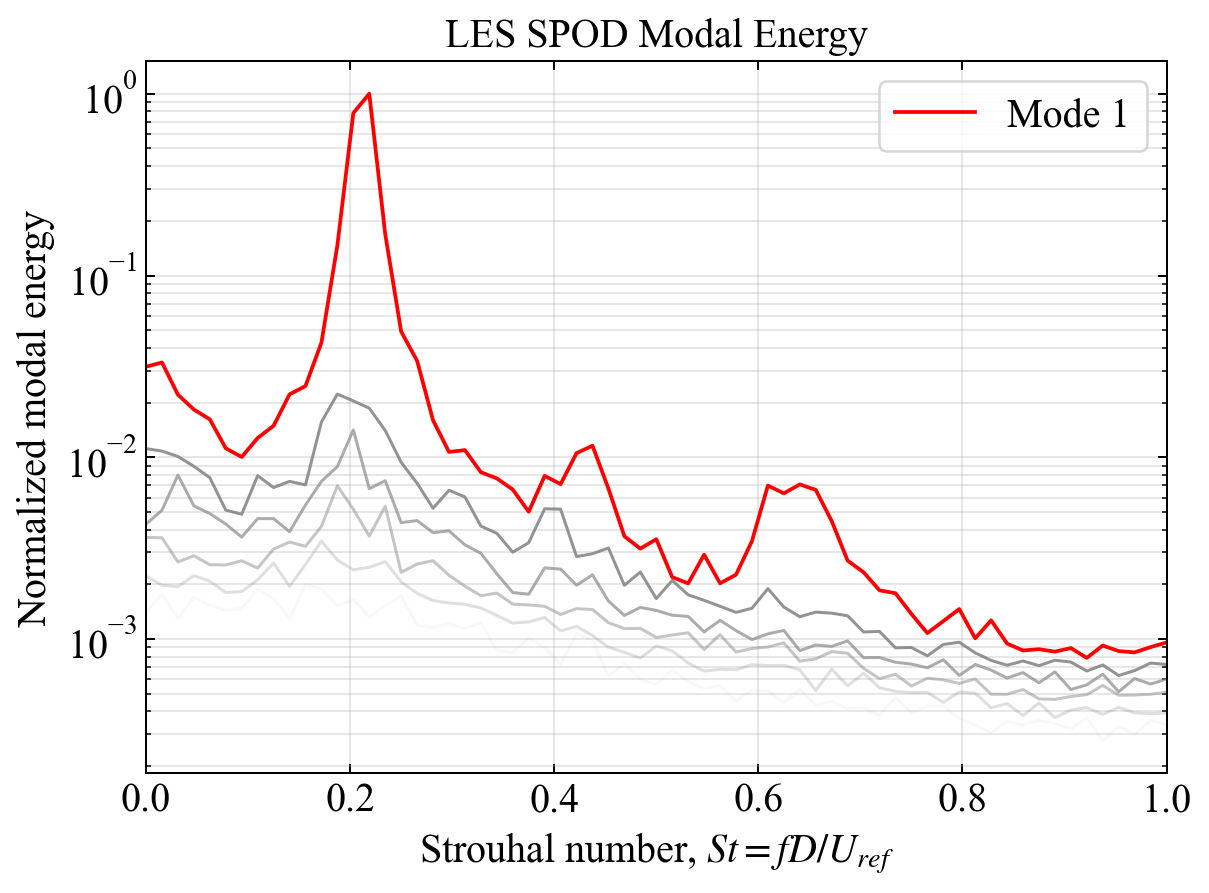

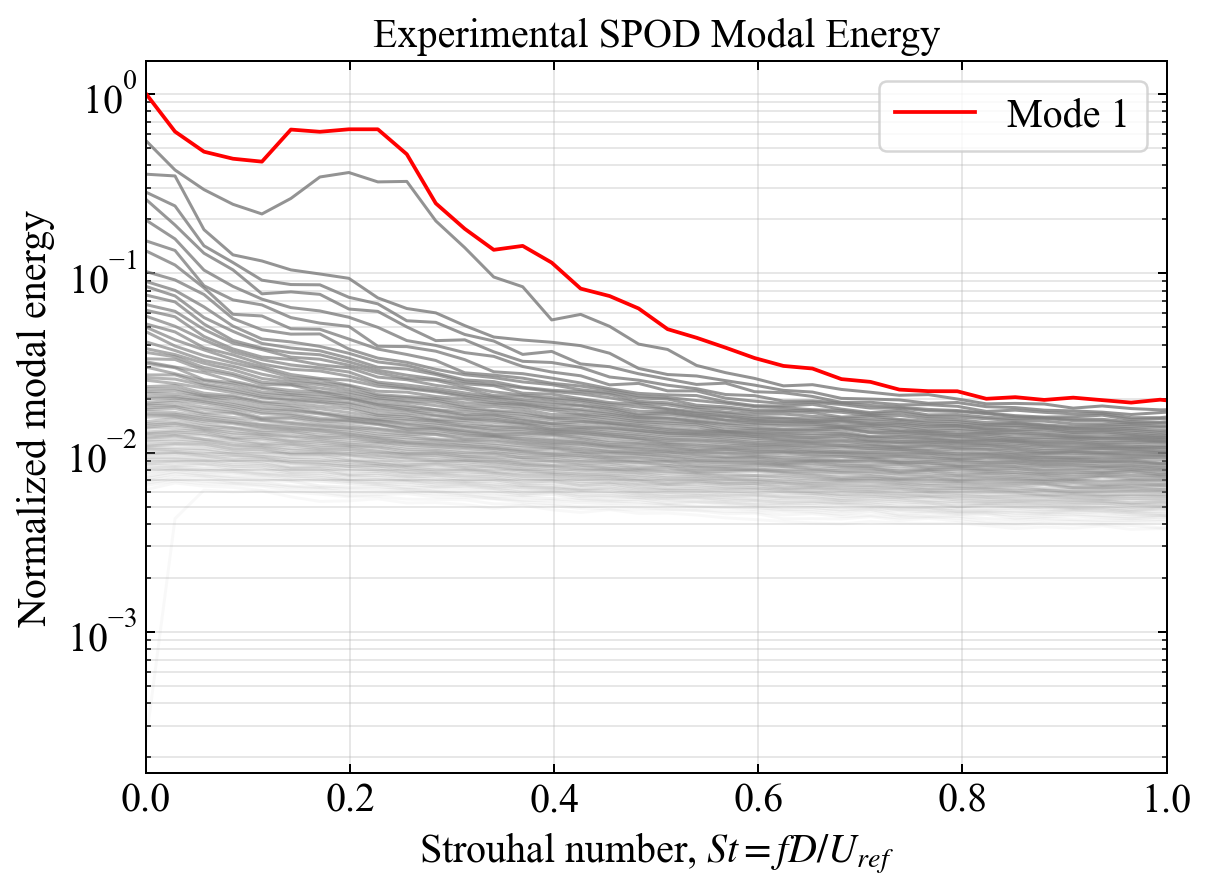

In [109]:
# ==========================================================
# NORMALIZED MODAL ENERGY
# ==========================================================
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

fig, ax = plot_spod_modal_energy(
    freqs_les,
    eigs_les,
    D=D_les,
    U_ref=U_les,
    normalize="global",
    xlim=(0, 1),
    logy=True,
)

ax.set_title("LES SPOD Modal Energy")


fig, ax = plot_spod_modal_energy(
    freqs_exp,
    eigs_exp,
    D=D_piv,
    U_ref=U_piv,
    normalize="global",
    xlim=(0, 1),
    logy=True,
)

ax.set_title("Experimental SPOD Modal Energy")

plt.show()

In [112]:
# ==========================================================
# SPOD MODE SPATIAL PLOT
# ==========================================================

def plot_spod_mode(
    X,
    Y,
    spod_modes,
    eigvals,
    freqs,
    D,
    U_ref,
    mode_idx=0,
    freq_idx=None,
    component="u",
    plot_type="real",
    levels=200,
    figsize=(7,5),
):
    """
    Plot SPOD spatial mode contour.

    component:
        "u", "v", or "mag"

    plot_type:
        "real", "imag", or "abs"
    """

    npts = X.size

    # ----------------------------------
    # Select dominant frequency
    # ----------------------------------
    if freq_idx is None:
        freq_idx = np.argmax(eigvals[:, mode_idx])

    mode = spod_modes[freq_idx, mode_idx]

    u_mode = mode[:npts].reshape(X.shape)
    v_mode = mode[npts:].reshape(X.shape)

    # ----------------------------------
    # Choose quantity
    # ----------------------------------
    if component == "u":
        field = u_mode

    elif component == "v":
        field = v_mode

    elif component == "mag":
        field = np.sqrt(
            np.abs(u_mode)**2 +
            np.abs(v_mode)**2
        )

    else:
        raise ValueError("component must be u, v or mag")

    # ----------------------------------
    # Real / Imag / Magnitude
    # ----------------------------------
    if plot_type == "real":
        field_plot = np.real(field)
        label = "Real"

    elif plot_type == "imag":
        field_plot = np.imag(field)
        label = "Imaginary"

    elif plot_type == "abs":
        field_plot = np.abs(field)
        label = "Magnitude"

    else:
        raise ValueError(
            "plot_type must be real, imag or abs"
        )

    # ----------------------------------
    # Strouhal number
    # ----------------------------------
    St = freqs[freq_idx] * D / U_ref

    # ----------------------------------
    # Plot
    # ----------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    cf = ax.contourf(
        X,
        Y,
        field_plot,
        levels=levels
    )

    plt.colorbar(cf, ax=ax)

    ax.set_aspect("equal")

    ax.set_xlabel("x/D")
    ax.set_ylabel("y/D")

    ax.set_title(
        f"SPOD Mode {mode_idx+1}\n"
        f"St = {St:.3f}"
    )

    plt.tight_layout()

    return fig, ax

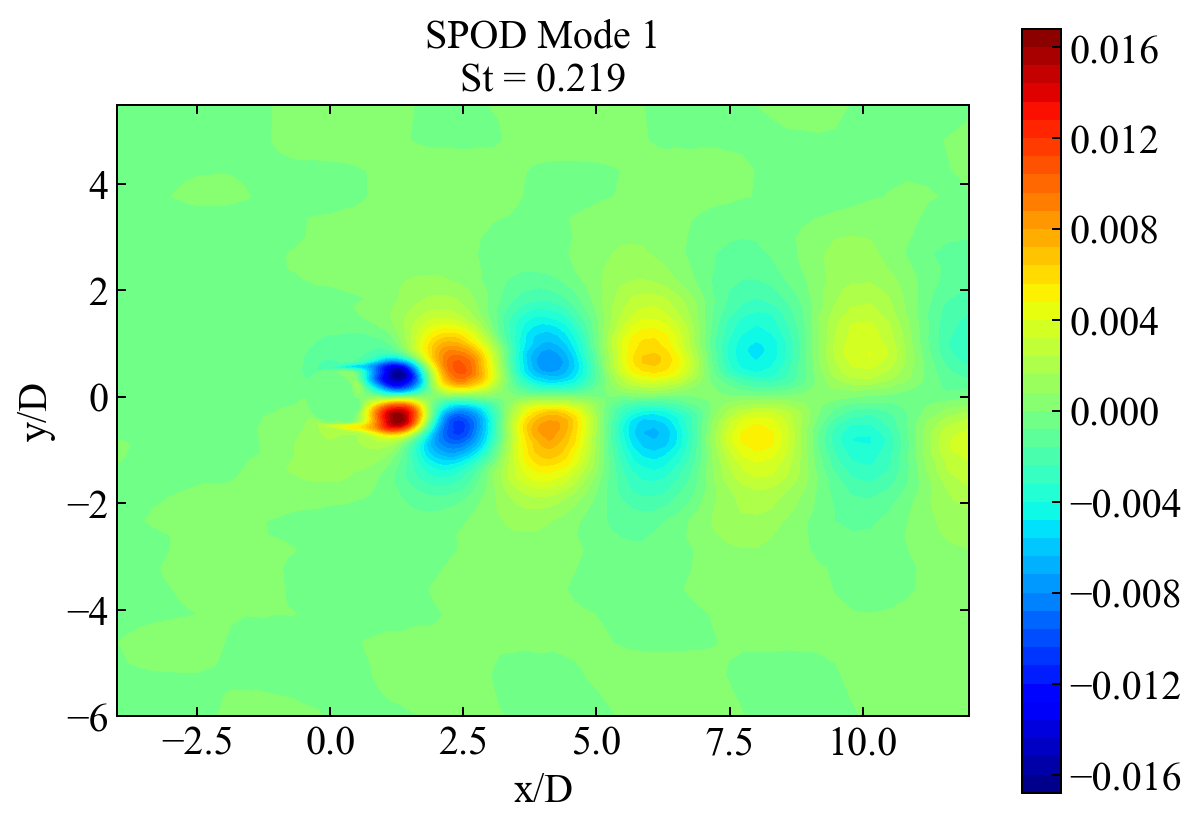

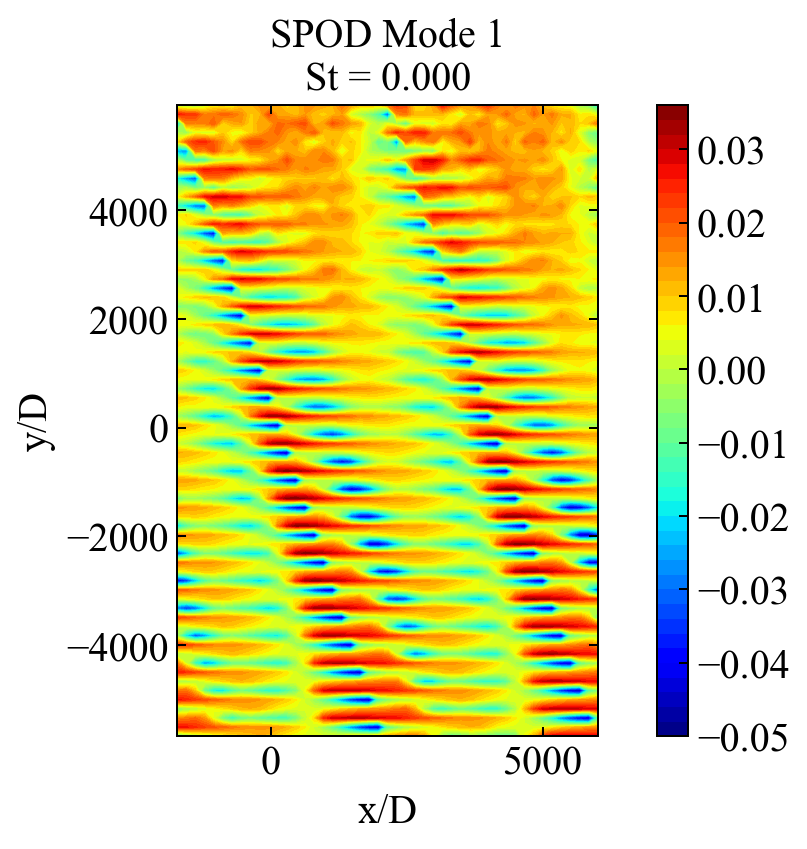

In [111]:
# ==========================================================
# LES SPOD MODE
# ==========================================================

plot_spod_mode(
    X_les / D_les,
    Y_les / D_les,
    modes_les,
    eigs_les,
    freqs_les,
    D=D_les,
    U_ref=U_les,
    mode_idx=0,
    freq_idx=freq_idx_manual,
    component="u",
    plot_type="real",
)

plt.show()


# ==========================================================
# EXP SPOD MODE
# ==========================================================

plot_spod_mode(
    X_exp / D_piv,
    Y_exp / D_piv,
    modes_exp,
    eigs_exp,
    freqs_exp,
    D=D_piv,
    U_ref=U_piv,
    mode_idx=0,
    freq_idx=freq_idx_manual,
    component="u",
    plot_type="real",
)

plt.show()